# VAYU — Data Preparation Pipeline
## Step 1: Project Setup + Exploratory Data Analysis

**Project:** Predictive Modeling and Unsupervised Clustering of Ambient Air Quality Across Indian Urban Centres Using CPCB Sensor Data

---

### What This Step Does
Before we touch a single value, we need to **fully understand what we are working with**. This is called Exploratory Data Analysis (EDA). Cleaning without EDA is like operating without a diagnosis — you will fix one thing and break three others.

### Steps in This Notebook
1. Create the output folder structure (one folder per ML task)
2. Load the primary dataset
3. Inspect column types, shapes, and basic statistics
4. Visualize missing values and sentinel value distribution
5. Understand geographic and temporal coverage
6. Map each column to its ML task

> **Rule:** No data is modified in this step. We only look.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 40)

print('Libraries loaded.')

Libraries loaded.


---
## Section 1 — Create Output Folder Structure

### Why Do We Separate Data by ML Task?

Different ML models have fundamentally different data requirements:

| Model | Target Variable | Features Needed | Data Requirement |
|---|---|---|---|
| Linear / Multiple Regression | AQI (numeric, continuous) | All 6 pollutants | No nulls in target or features |
| Logistic Regression / KNN / SVM / Trees | AQI_category (6 classes) | All 6 pollutants | Balanced classes, scaled features |
| K-Means Clustering | None (unsupervised) | City-level AQI profiles | Standardized, no target column |
| PCA / t-SNE / SVD | None (dimensionality reduction) | Pollutant feature matrix | Standardized, numeric only |

Mixing these into one file causes confusion and data leakage. Each folder gets its own cleaned dataset with a README explaining what it contains and why.

In [2]:
DATA_ROOT   = './data'
OUTPUT_ROOT = './data/cleaned'

FOLDERS = {
    '01_regression': (
        'Linear Regression + Multiple Regression (Lectures 8-17)\n'
        'Target     : AQI (numeric, 0-500)\n'
        'Features   : PM2.5, PM10, NO2, SO2, CO, O3 + time features\n'
        'Source     : aqi_india_38cols_knn_final.csv (842k rows, 29 cities)\n'
        'Why this   : Has all 6 pollutants as features + pre-computed numeric AQI as target\n'
        'Rejected   : Bulletin files (no raw pollutant readings, only final AQI)'
    ),
    '02_classification': (
        'Logistic Regression, KNN, SVM, Decision Trees, Random Forest (Lectures 18-24, 31-36, 56-60)\n'
        'Target     : AQI_category (Good/Satisfactory/Moderate/Poor/Very Poor/Severe)\n'
        'Features   : PM2.5, PM10, NO2, SO2, CO, O3 + time + city encoding\n'
        'Source     : Same primary file, different target column\n'
        'Why this   : AQI_category derived from AQI using CPCB breakpoints\n'
        'Rejected   : Bulletin files (no pollutant features to train on)'
    ),
    '03_clustering': (
        'K-Means Clustering (Lectures 55-56)\n'
        'Target     : None — unsupervised\n'
        'Features   : City-level mean AQI per season, prominent pollutant frequency\n'
        'Source     : All 277 AQI Bulletin files (one per city, 300k rows total)\n'
        'Why this   : Covers 277 Indian cities with daily AQI history — best for city clustering\n'
        'Rejected   : aqi_india_38cols (29 cities only, too few for geographic clustering)'
    ),
    '04_dimensionality': (
        'PCA, t-SNE, SVD (Lectures 46-54)\n'
        'Target     : None — used for visualization and feature reduction\n'
        'Features   : 6 pollutant concentrations (numeric, standardized)\n'
        'Source     : Same primary file, pollutant columns only\n'
        'Why this   : PCA needs a pure numeric matrix with no categorical cols\n'
        'Rejected   : Bulletin files (no raw pollutant values, only aggregated AQI)'
    ),
    '05_shared': (
        'Master cleaned file\n'
        'This is the output of the full cleaning pipeline.\n'
        'All other folders are derived subsets of this file.\n'
        'Use this when you want to cross-check or do custom analysis.'
    ),
}

os.makedirs(OUTPUT_ROOT, exist_ok=True)

for folder, description in FOLDERS.items():
    path = os.path.join(OUTPUT_ROOT, folder)
    os.makedirs(path, exist_ok=True)
    with open(os.path.join(path, 'README.txt'), 'w') as f:
        f.write(f'VAYU — {folder}\n')
        f.write('=' * 60 + '\n\n')
        f.write(description + '\n')
    print(f'  Created: {path}')

print('\nFolder structure ready.')

  Created: ./data/cleaned/01_regression
  Created: ./data/cleaned/02_classification
  Created: ./data/cleaned/03_clustering
  Created: ./data/cleaned/04_dimensionality
  Created: ./data/cleaned/05_shared

Folder structure ready.


---
## Section 2 — Load the Primary Dataset

### Why `aqi_india_38cols_knn_final.csv`?

From our earlier audit of all 299 files, we found this file has:
- **842,160 rows** across **29 Indian cities**
- All 6 pollutants required for AQI calculation: PM2.5, PM10, NO2, SO2, CO, O3
- Already **KNN-imputed** — 0% standard missing values
- Still contains **sentinel value 999** — CPCB code for sensor error. Not a real reading. We fix this in Step 2.
- Covers **2015 to 2024** — long enough for seasonal and yearly trend analysis

All other files either lack pollutant columns (bulletin files), cover too few cities, or are redundant versions of this dataset.

In [3]:
PRIMARY_FILE = os.path.join(DATA_ROOT, 'aqi_india_38cols_knn_final.csv')

print(f'Loading: {PRIMARY_FILE}')
print('This will take ~15 seconds for 842k rows...\n')

df = pd.read_csv(PRIMARY_FILE, low_memory=False)

print(f'Shape   : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

Loading: ./data/aqi_india_38cols_knn_final.csv
This will take ~15 seconds for 842k rows...

Shape   : 842,160 rows  x  31 columns
Memory  : 548.0 MB


---
## Section 3 — Column Inventory

### Why Check Data Types First?

Same reason as in any real-world preprocessing workflow:
- If a numeric column is stored as `object` (string), `df.describe()` will not compute statistics
- You cannot compute outliers or correlations on string columns
- Sentinel values (like 999 stored as int) will NOT be caught by `isnull()` checks

We colour-code columns into 4 roles: **Identity** (city, date), **Pollutants** (our features), **Target** (AQI), and **Datetime** (time features).

In [4]:
print('ALL COLUMNS — dtype, null count, and sample value:')
print('=' * 70)
col_info = pd.DataFrame({
    'column'   : df.columns,
    'dtype'    : df.dtypes.values,
    'nulls'    : df.isnull().sum().values,
    'null_pct' : (df.isnull().mean() * 100).round(2).values,
    'sample'   : [str(df[c].dropna().iloc[0])[:35] if df[c].notna().any() else 'ALL NULL'
                  for c in df.columns]
})
display(col_info)

ALL COLUMNS — dtype, null count, and sample value:


,column,dtype,nulls,null_pct,sample
0,city,str,0,0.0,agartala
1,state,str,0,0.0,tripura
2,latitude,float64,0,0.0,23.8315
3,longitude,float64,0,0.0,91.2868
4,datetime,str,0,0.0,2022-08-05 00:00:00
5,month,float64,0,0.0,8.0
6,day_name,str,0,0.0,friday
7,is_weekend,bool,0,0.0,False
8,season,str,0,0.0,monsoon
9,time_of_day,str,0,0.0,night


COLUMN ROLE SUMMARY:
  [OTHER     ]  10 cols — ['humidity_percent', 'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining', 'heavy_rain']
  [POLLUTANT ]   8 cols — ['cloud_cover_percent', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3']
  [DATETIME  ]   7 cols — ['datetime', 'month', 'day_name', 'is_weekend', 'season', 'time_of_day']
  [IDENTITY  ]   4 cols — ['city', 'state', 'latitude', 'longitude']
  [TARGET    ]   2 cols — ['us_aqi', 'aqi_category']


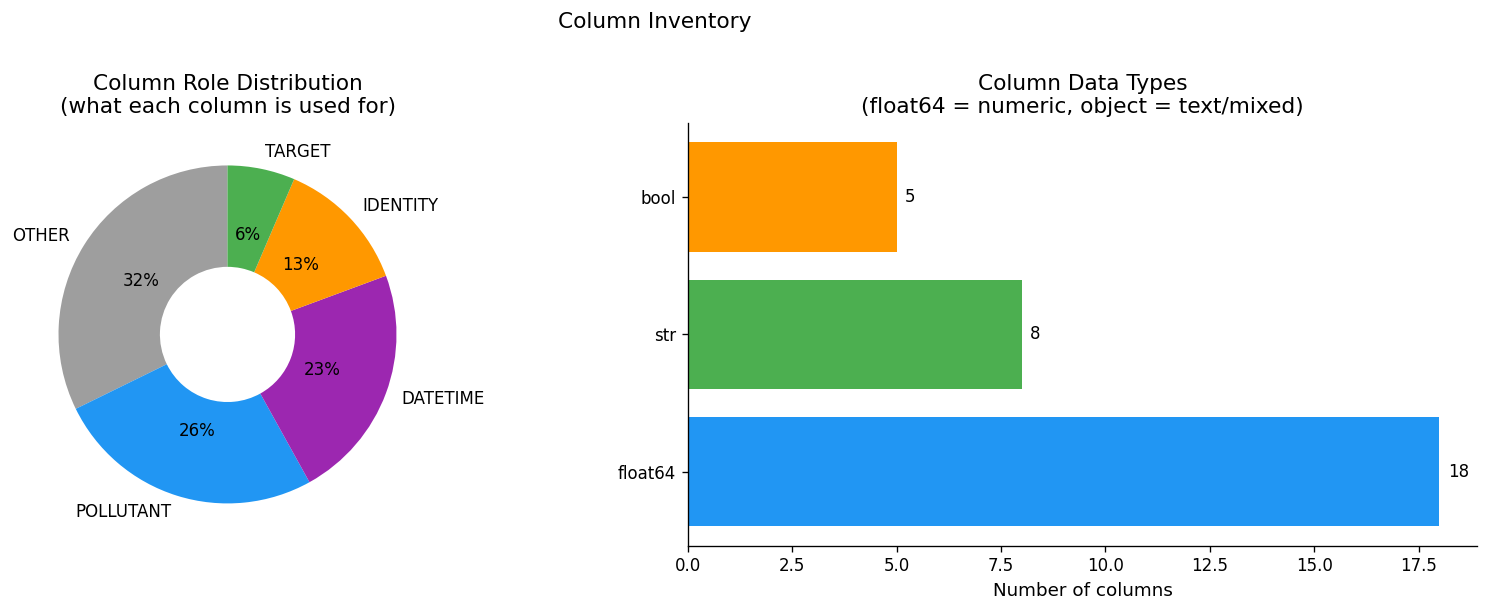

In [5]:
POLLUTANT_KEYWORDS = ['pm2', 'pm10', 'no2', 'so2', 'co', 'o3', 'ozone', 'nh3', 'nox']
TARGET_KEYWORDS    = ['aqi', 'category', 'bucket', 'index']
IDENTITY_KEYWORDS  = ['city', 'state', 'station', 'lat', 'lon', 'location']
DATETIME_KEYWORDS  = ['date', 'time', 'year', 'month', 'day', 'hour', 'week', 'season']

col_roles = {}
for col in df.columns:
    cl = col.lower()
    if   any(k in cl for k in POLLUTANT_KEYWORDS): col_roles[col] = 'POLLUTANT'
    elif any(k in cl for k in TARGET_KEYWORDS):    col_roles[col] = 'TARGET'
    elif any(k in cl for k in IDENTITY_KEYWORDS):  col_roles[col] = 'IDENTITY'
    elif any(k in cl for k in DATETIME_KEYWORDS):  col_roles[col] = 'DATETIME'
    else:                                          col_roles[col] = 'OTHER'

role_colors = {
    'POLLUTANT': '#2196F3',
    'TARGET'   : '#4CAF50',
    'IDENTITY' : '#FF9800',
    'DATETIME' : '#9C27B0',
    'OTHER'    : '#9E9E9E',
}

role_counts = pd.Series(col_roles).value_counts()

print('COLUMN ROLE SUMMARY:')
for role, count in role_counts.items():
    cols_in_role = [c for c, r in col_roles.items() if r == role]
    print(f'  [{role:<10}] {count:>3} cols — {cols_in_role[:6]}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    role_counts.values,
    labels=role_counts.index,
    colors=[role_colors[r] for r in role_counts.index],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title('Column Role Distribution\n(what each column is used for)')

dtype_counts = df.dtypes.astype(str).value_counts()
axes[1].barh(dtype_counts.index, dtype_counts.values,
             color=['#2196F3','#4CAF50','#FF9800','#9E9E9E'][:len(dtype_counts)])
for i, v in enumerate(dtype_counts.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=10)
axes[1].set_xlabel('Number of columns')
axes[1].set_title('Column Data Types\n(float64 = numeric, object = text/mixed)')

plt.suptitle('Column Inventory', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 4 — Missing Values + Sentinel Value Detection

### Two Types of Missing Data in This Dataset

Standard `isnull()` will show 0% missing because this file was already KNN-imputed. But there is a second hidden type:

**Sentinel value 999** — CPCB sensor systems write `999` when a sensor fails or goes offline. It is NOT a real measurement. PM2.5 of 999 µg/m³ is physically impossible. If you train a model on these, the model will learn completely wrong relationships between pollutants and AQI.

We visualize both: standard NaN per column, and count of sentinel 999 per pollutant.

Columns with standard NaN  : 1
Columns with sentinel 999  : 2
Total sentinel 999 values  : 1,477


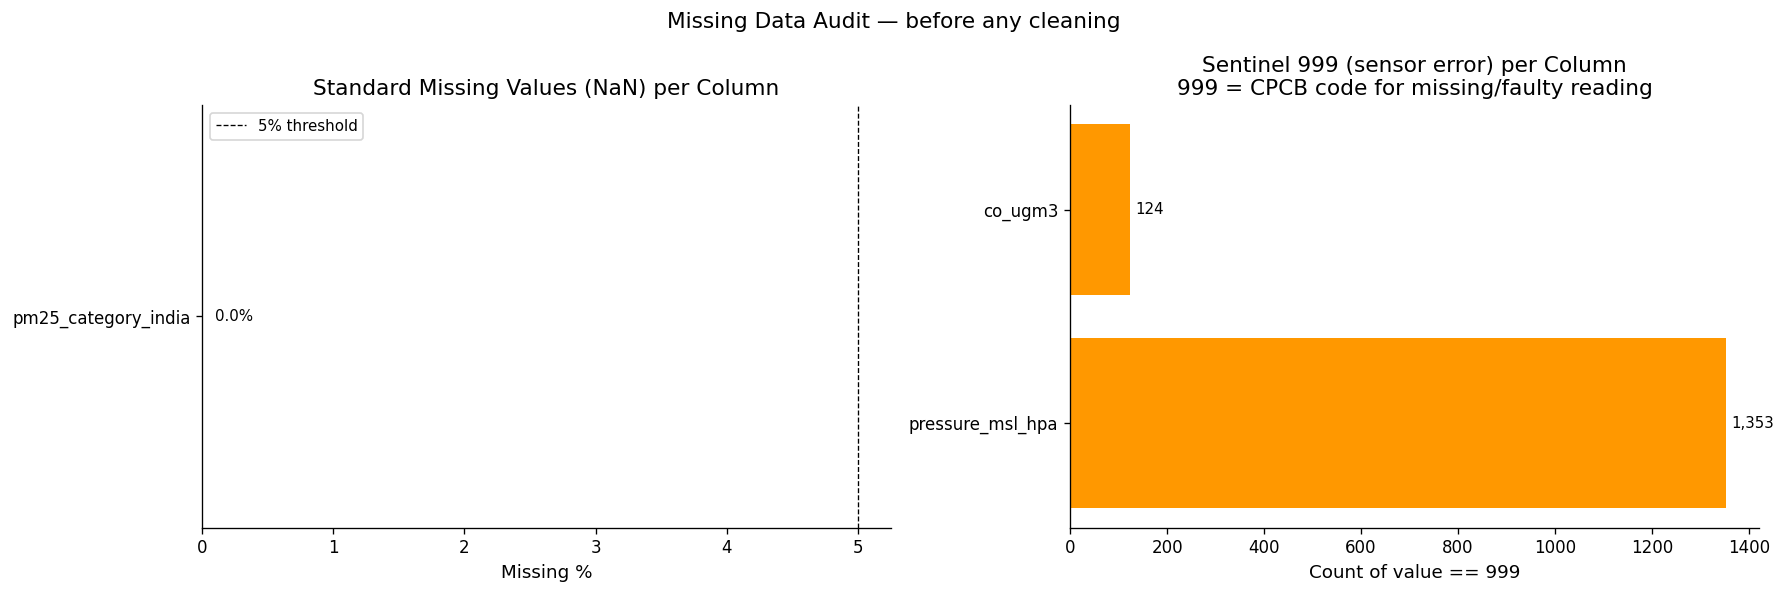

In [6]:
null_pct = df.isnull().mean() * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

numeric_cols = df.select_dtypes(include=[np.number]).columns
sentinel_counts = {}
for col in numeric_cols:
    count = (df[col] == 999).sum()
    if count > 0:
        sentinel_counts[col] = count

sentinel_series = pd.Series(sentinel_counts).sort_values(ascending=False)

print(f'Columns with standard NaN  : {len(null_pct)}')
print(f'Columns with sentinel 999  : {len(sentinel_series)}')
print(f'Total sentinel 999 values  : {sentinel_series.sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if len(null_pct) > 0:
    bars = axes[0].barh(null_pct.index, null_pct.values, color='#EF5350')
    axes[0].axvline(5, color='black', linestyle='--', linewidth=0.8, label='5% threshold')
    axes[0].set_xlabel('Missing %')
    axes[0].set_title('Standard Missing Values (NaN) per Column')
    axes[0].legend(fontsize=9)
    for bar, val in zip(bars, null_pct.values):
        axes[0].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
else:
    axes[0].text(0.5, 0.5, 'No standard NaN found\n(file was KNN-imputed)',
                 ha='center', va='center', fontsize=12,
                 transform=axes[0].transAxes, color='green')
    axes[0].set_title('Standard Missing Values (NaN) per Column')

if len(sentinel_series) > 0:
    top_s = sentinel_series.head(15)
    bars2 = axes[1].barh(top_s.index, top_s.values, color='#FF9800')
    axes[1].set_xlabel('Count of value == 999')
    axes[1].set_title('Sentinel 999 (sensor error) per Column\n999 = CPCB code for missing/faulty reading')
    for bar, val in zip(bars2, top_s.values):
        axes[1].text(val + 10, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'No sentinel 999 values found',
                 ha='center', va='center', fontsize=12,
                 transform=axes[1].transAxes, color='green')
    axes[1].set_title('Sentinel Value 999 per Column')

plt.suptitle('Missing Data Audit — before any cleaning', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 5 — Geographic and Temporal Coverage

### Why Does Coverage Matter?

Before training any model, you need to know:
- **Which cities** are in the data — are major polluted cities (Delhi, Patna) represented?
- **How many rows per city** — are some cities massively over-represented? This causes the model to be biased toward those cities.
- **What time range** — is the data recent? Does it cover winter months (peak pollution)?

Unequal city representation means you may need to **stratify** your train/test split by city — covered in Lectures 27–30.

City column     : city
Datetime column : datetime


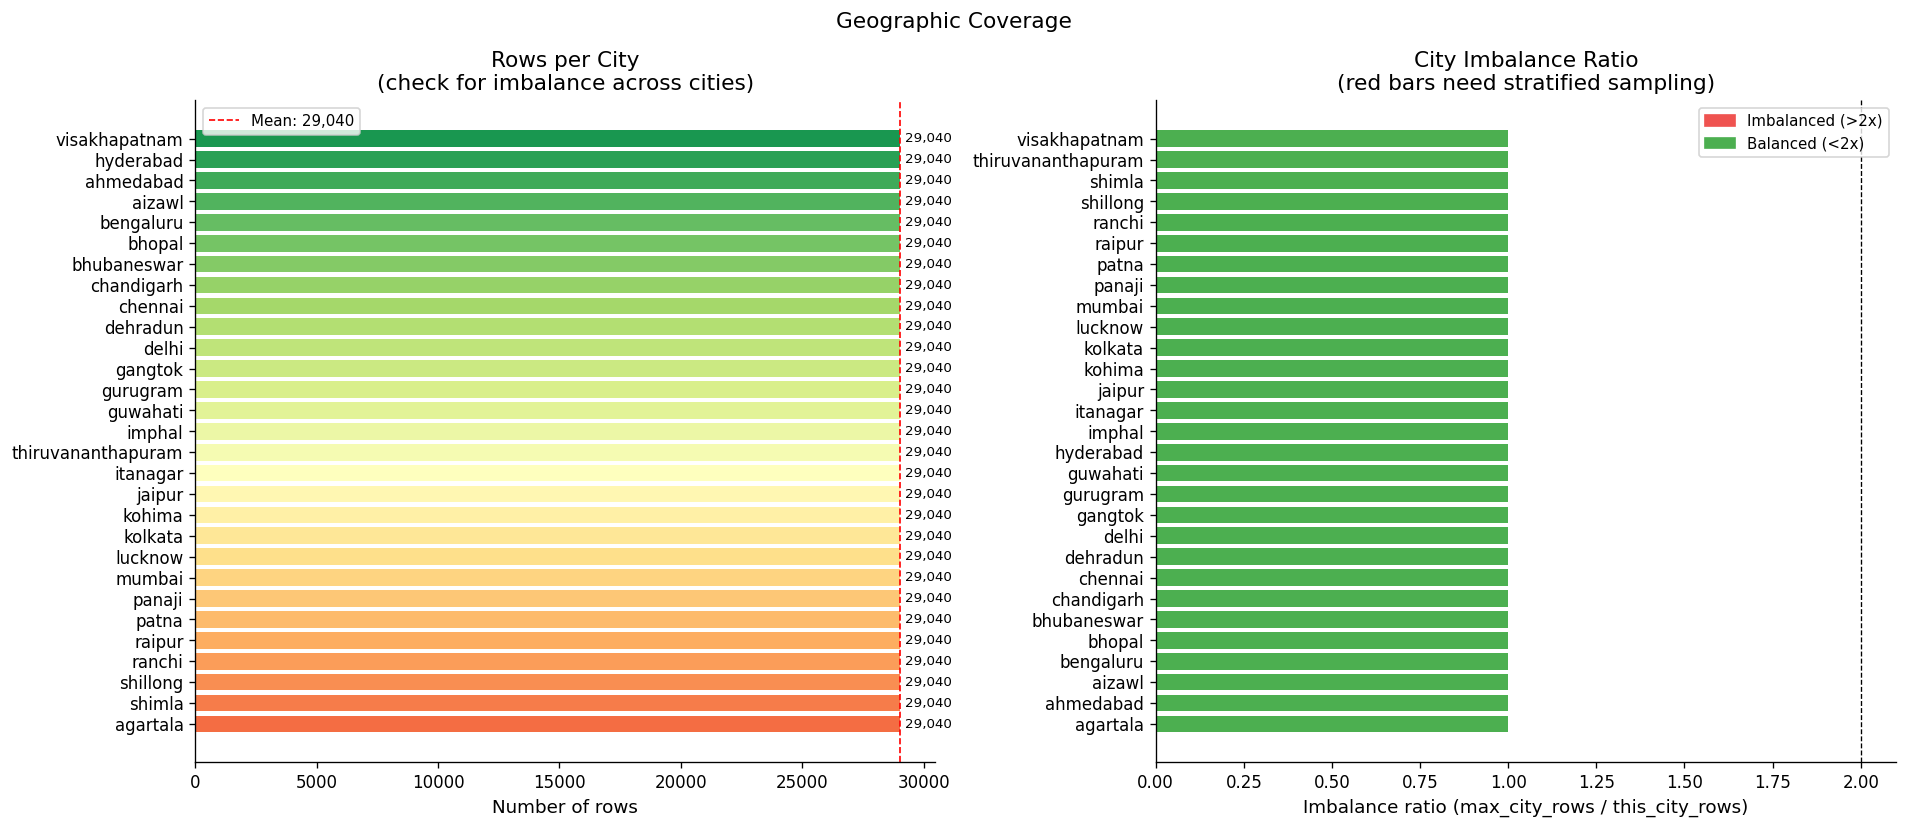

Total cities  : 29
Max rows      : 29,040  (agartala)
Min rows      : 29,040  (agartala)
Imbalance     : 1.0x


In [7]:
city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns
                 if 'datetime' in c.lower() or c.lower() == 'date'
                 or 'timestamp' in c.lower()), None)

print(f'City column     : {city_col}')
print(f'Datetime column : {date_col}')

if city_col:
    city_counts = df[city_col].value_counts().sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    colors_city = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(city_counts)))
    bars = axes[0].barh(city_counts.index, city_counts.values, color=colors_city)
    axes[0].axvline(city_counts.mean(), color='red', linestyle='--',
                    linewidth=1, label=f'Mean: {city_counts.mean():,.0f}')
    axes[0].set_xlabel('Number of rows')
    axes[0].set_title('Rows per City\n(check for imbalance across cities)')
    axes[0].legend(fontsize=9)
    for bar, val in zip(bars, city_counts.values):
        axes[0].text(val + 200, bar.get_y() + bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=8)

    imbalance = (city_counts.max() / city_counts).sort_values(ascending=True)
    colors_imb = ['#EF5350' if v > 2 else '#4CAF50' for v in imbalance.values]
    axes[1].barh(imbalance.index, imbalance.values, color=colors_imb)
    axes[1].axvline(2, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_xlabel('Imbalance ratio (max_city_rows / this_city_rows)')
    axes[1].set_title('City Imbalance Ratio\n(red bars need stratified sampling)')

    red_patch   = mpatches.Patch(color='#EF5350', label='Imbalanced (>2x)')
    green_patch = mpatches.Patch(color='#4CAF50', label='Balanced (<2x)')
    axes[1].legend(handles=[red_patch, green_patch], fontsize=9)

    plt.suptitle('Geographic Coverage', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'Total cities  : {len(city_counts)}')
    print(f'Max rows      : {city_counts.max():,}  ({city_counts.idxmax()})')
    print(f'Min rows      : {city_counts.min():,}  ({city_counts.idxmin()})')
    print(f'Imbalance     : {city_counts.max()/city_counts.min():.1f}x')

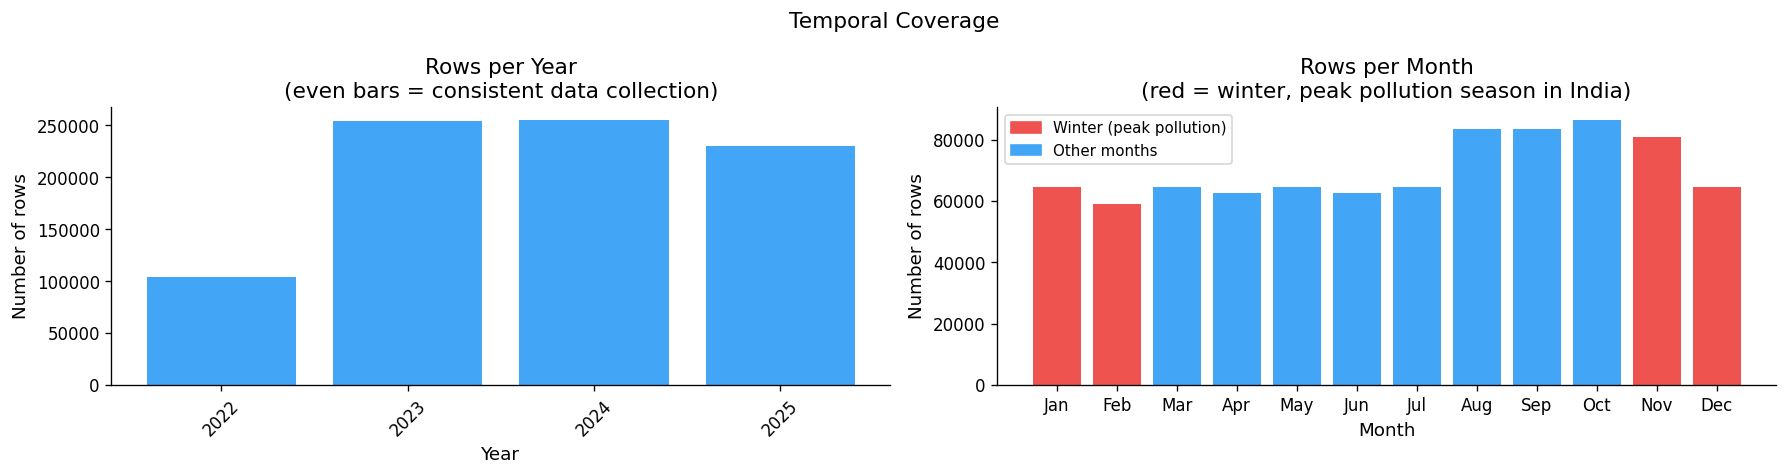

Date range : 2022-08-05  to  2025-11-26


In [8]:
if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['_year']  = df[date_col].dt.year
    df['_month'] = df[date_col].dt.month

    year_counts  = df['_year'].value_counts().sort_index()
    month_counts = df['_month'].value_counts().sort_index()
    month_names  = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    axes[0].bar(year_counts.index.astype(str), year_counts.values, color='#42A5F5')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Number of rows')
    axes[0].set_title('Rows per Year\n(even bars = consistent data collection)')
    axes[0].tick_params(axis='x', rotation=45)

    m_idx    = month_counts.index.tolist()
    m_names  = [month_names[m-1] for m in m_idx]
    m_colors = ['#EF5350' if m in [11,12,1,2] else '#42A5F5' for m in m_idx]
    axes[1].bar(m_names, month_counts.values, color=m_colors)
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Number of rows')
    axes[1].set_title('Rows per Month\n(red = winter, peak pollution season in India)')
    red_p  = mpatches.Patch(color='#EF5350', label='Winter (peak pollution)')
    blue_p = mpatches.Patch(color='#42A5F5', label='Other months')
    axes[1].legend(handles=[red_p, blue_p], fontsize=9)

    plt.suptitle('Temporal Coverage', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'Date range : {df[date_col].min().date()}  to  {df[date_col].max().date()}')
    df.drop(columns=['_year', '_month'], inplace=True)

---
## Section 6 — Raw Pollutant Distributions

### Why Look at Distributions Before Cleaning?

The raw distribution of each pollutant tells us:
- **Sentinel 999 spike** — appears as a bar far to the right of all real values
- **Skewness** — a right-skewed distribution (long tail to the right) may need log transformation before linear regression, since linear regression assumes features are roughly normally distributed
- **Physical outliers** — values above the physically possible maximum (e.g., PM2.5 > 1000) are sensor errors that should be nulled

We save these as our **before-cleaning baseline**. In Step 2 we will show the same plots after cleaning so you can see the exact effect of each cleaning operation.

Pollutant columns: ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']


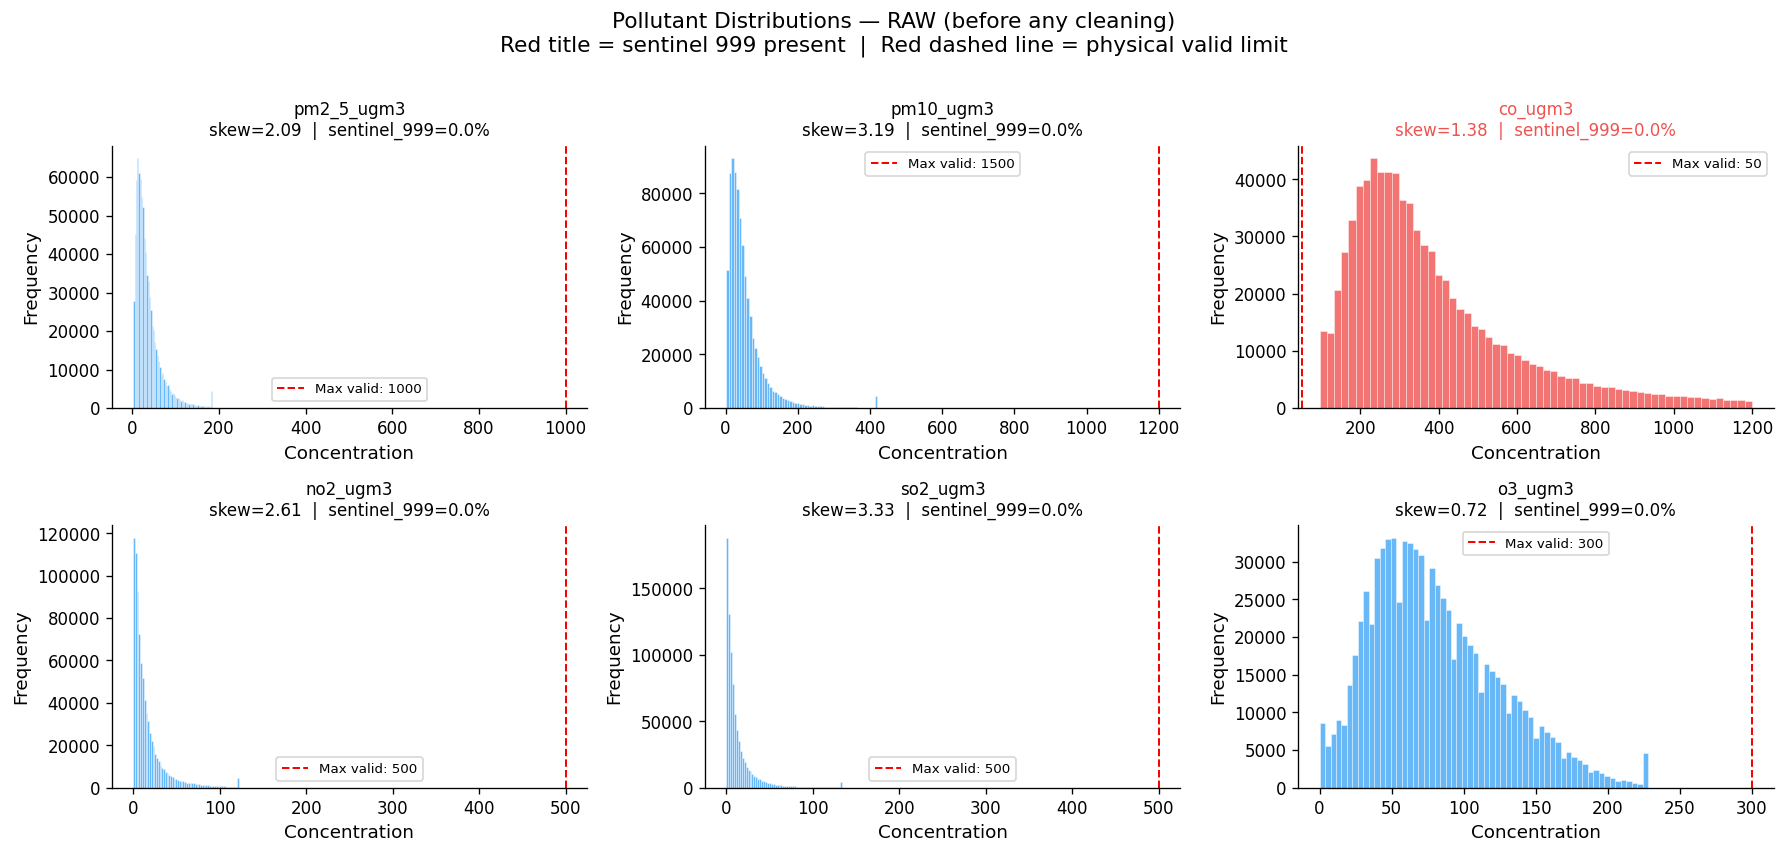

In [9]:
POLL_KEYWORDS   = ['pm2', 'pm10', 'no2', 'so2', ' co', 'co_', 'ozone', 'o3', 'nh3']
pollutant_cols  = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLL_KEYWORDS)
]

VALID_MAX = {'pm2':1000,'pm10':1500,'no2':500,'so2':500,
             'co':50,'ozone':300,'o3':300,'nh3':400}

print(f'Pollutant columns: {pollutant_cols}')

if pollutant_cols:
    n     = len(pollutant_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
    axes = axes.flatten()

    for i, col in enumerate(pollutant_cols):
        vals     = pd.to_numeric(df[col], errors='coerce').dropna()
        vals_vis = vals[vals <= 1200]

        sentinel_pct = (vals == 999).mean() * 100
        skewness     = vals_vis.skew()

        color = '#EF5350' if sentinel_pct > 0 else '#42A5F5'
        axes[i].hist(vals_vis, bins=60, color=color, edgecolor='white', linewidth=0.3, alpha=0.8)
        axes[i].set_title(
            f'{col}\nskew={skewness:.2f}  |  sentinel_999={sentinel_pct:.1f}%',
            fontsize=10,
            color='#EF5350' if sentinel_pct > 0 else 'black'
        )
        axes[i].set_xlabel('Concentration')
        axes[i].set_ylabel('Frequency')

        for kw, maxval in VALID_MAX.items():
            if kw in col.lower():
                axes[i].axvline(min(maxval, 1200), color='red', linestyle='--',
                                linewidth=1.2, label=f'Max valid: {maxval}')
                axes[i].legend(fontsize=8)
                break

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        'Pollutant Distributions — RAW (before any cleaning)\n'
        'Red title = sentinel 999 present  |  Red dashed line = physical valid limit',
        fontsize=13, y=1.01
    )
    plt.tight_layout()
    plt.show()

---
## Section 7 — Target Variable Overview

### What Are We Actually Predicting?

For **regression** → target is numeric AQI (0–500).  
For **classification** → target is AQI category, a label derived from AQI using CPCB breakpoints.

Key thing to check: **class balance**. If 80% of rows are "Moderate" and only 2% are "Severe", the model will almost never predict Severe. This is the **imbalanced dataset** problem covered in Lectures 39–41, and we will handle it in Step 4 using oversampling or class weights.

AQI numeric col  : None
AQI category col : aqi_category

Class distribution:
aqi_category
Moderate                          385833
Unhealthy For Sensitive Groups    175125
Good                              136476
Unhealthy                         130360
Very Unhealthy                     14366

Imbalance ratio: 2.8x  (majority/minority class)


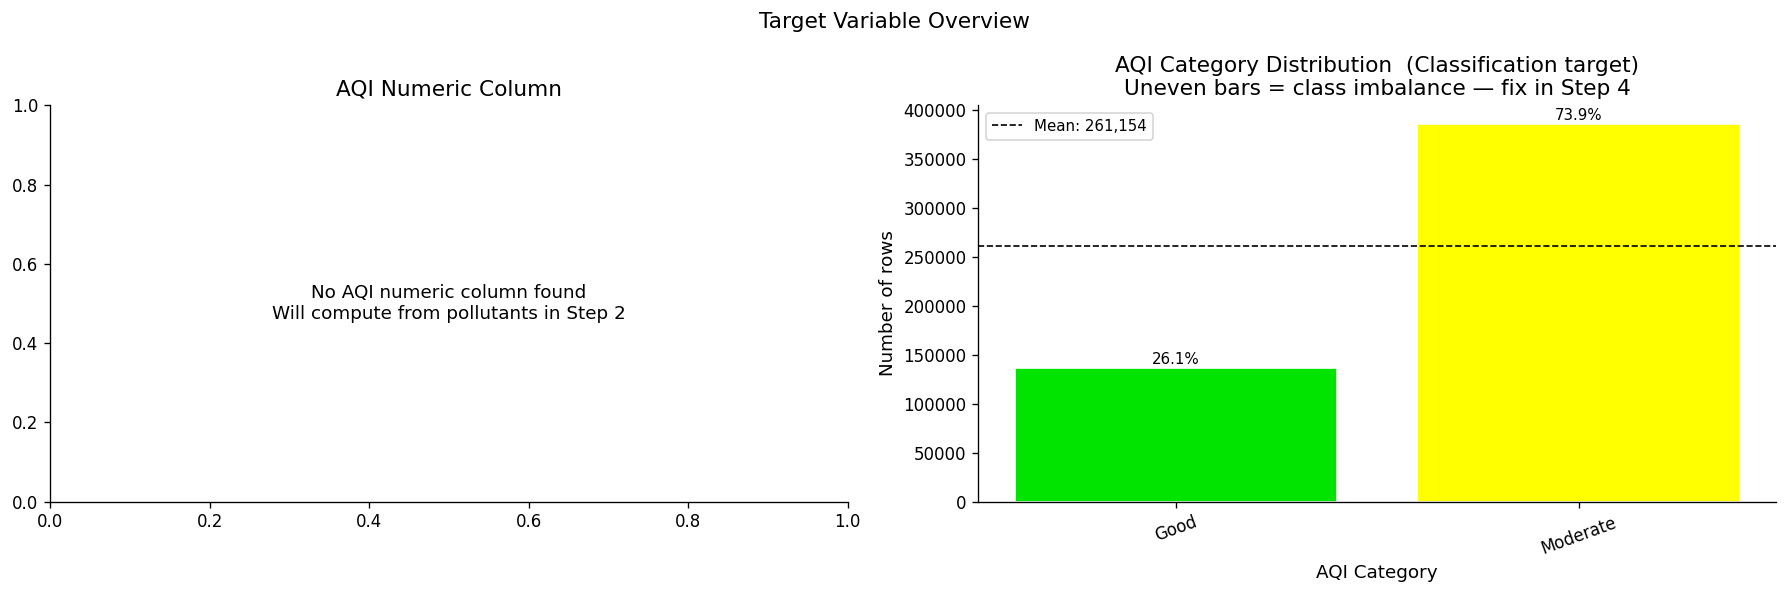

In [10]:
aqi_col = next((c for c in df.columns if c.lower() in ['aqi','air_quality_index']), None)
cat_col = next((c for c in df.columns
                if 'category' in c.lower() or 'bucket' in c.lower()), None)

print(f'AQI numeric col  : {aqi_col}')
print(f'AQI category col : {cat_col}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: AQI numeric distribution with CPCB bands
if aqi_col:
    aqi_vals  = pd.to_numeric(df[aqi_col], errors='coerce')
    aqi_clean = aqi_vals[(aqi_vals >= 0) & (aqi_vals <= 500)]

    band_edges  = [0, 50, 100, 200, 300, 400, 500]
    band_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']
    band_labels = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']

    axes[0].hist(aqi_clean, bins=80, color='#90CAF9', edgecolor='white', linewidth=0.2)
    for lo, hi, cb in zip(band_edges[:-1], band_edges[1:], band_colors):
        axes[0].axvspan(lo, hi, alpha=0.12, color=cb)
    for edge, label, cb in zip(band_edges[1:], band_labels, band_colors):
        axes[0].axvline(edge, color=cb, linewidth=0.8, linestyle='--')

    axes[0].set_xlabel('AQI Value')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(
        f'AQI Distribution  (Regression target)\nmean={aqi_clean.mean():.0f}  |  median={aqi_clean.median():.0f}'
    )
else:
    axes[0].text(0.5, 0.5, 'No AQI numeric column found\nWill compute from pollutants in Step 2',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=11)
    axes[0].set_title('AQI Numeric Column')

# Right: category balance
if cat_col:
    cat_order  = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
    cat_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']
    cat_vals   = df[cat_col].astype(str).str.strip().str.title()
    counts     = cat_vals.value_counts().reindex(cat_order).dropna()
    pcts       = (counts / counts.sum() * 100).round(1)
    clrs       = [cat_colors[cat_order.index(c)] for c in counts.index if c in cat_order]

    bars = axes[1].bar(counts.index, counts.values, color=clrs, edgecolor='white')
    axes[1].axhline(counts.mean(), color='black', linestyle='--',
                    linewidth=1, label=f'Mean: {counts.mean():,.0f}')
    for bar, pct in zip(bars, pcts.values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + counts.max()*0.01,
                     f'{pct:.1f}%', ha='center', fontsize=9)
    axes[1].set_xlabel('AQI Category')
    axes[1].set_ylabel('Number of rows')
    axes[1].set_title('AQI Category Distribution  (Classification target)\nUneven bars = class imbalance — fix in Step 4')
    axes[1].legend(fontsize=9)
    axes[1].tick_params(axis='x', rotation=20)

    print('\nClass distribution:')
    print(cat_vals.value_counts().to_string())
    minority = counts.min()
    majority = counts.max()
    print(f'\nImbalance ratio: {majority/minority:.1f}x  (majority/minority class)')
    if majority/minority > 3:
        print('WARNING: Severe class imbalance. Will use SMOTE or class_weight in Step 4.')
else:
    axes[1].text(0.5, 0.5, 'No AQI category column found\nWill derive from AQI values in Step 2',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=11)
    axes[1].set_title('AQI Category Column')

plt.suptitle('Target Variable Overview', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 8 — Correlation Heatmap (Raw)

### Why Check Correlations Before Cleaning?

Correlation tells us how strongly two variables move together. For ML:
- **High correlation between features** (e.g., PM2.5 and PM10 are both dust particles) = **multicollinearity**. Linear regression models get confused when two features are highly correlated — covered in Lectures 10–12.
- **High correlation between a feature and the target** = that feature is a strong predictor. PM2.5 and AQI should be highly correlated since PM2.5 is the dominant pollutant in India.

We check this raw (with sentinels still in) to see the baseline, then compare after cleaning in Step 2.

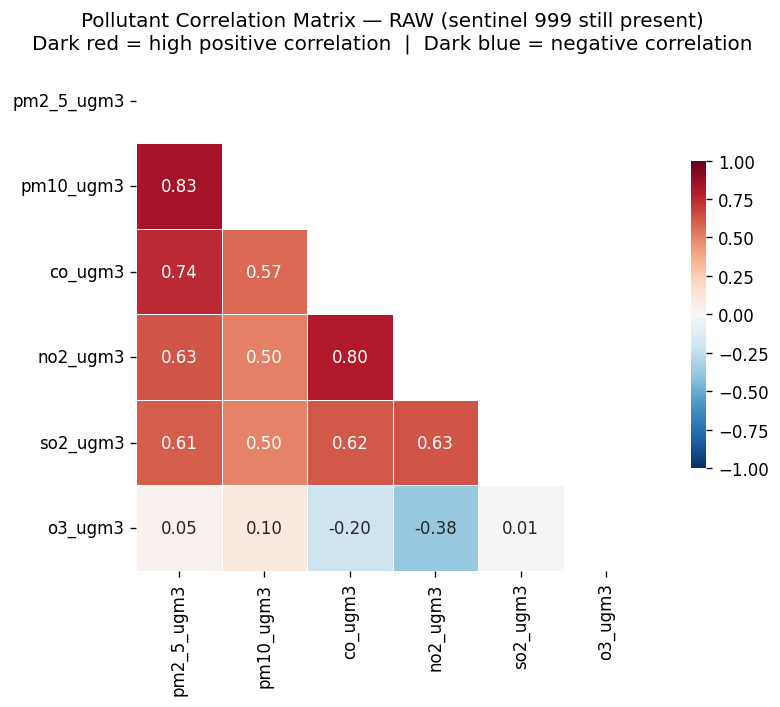

In [11]:
corr_cols = pollutant_cols.copy()
if aqi_col:
    corr_cols.append(aqi_col)

if len(corr_cols) >= 2:
    corr_df  = df[corr_cols].apply(pd.to_numeric, errors='coerce')
    corr_mat = corr_df.corr()

    fig, ax = plt.subplots(figsize=(max(8, len(corr_cols)), max(6, len(corr_cols)-1)))
    mask = np.triu(np.ones_like(corr_mat, dtype=bool))
    sns.heatmap(
        corr_mat, mask=mask, annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        square=True, linewidths=0.5, ax=ax,
        cbar_kws={'shrink': 0.6}
    )
    ax.set_title(
        'Pollutant Correlation Matrix — RAW (sentinel 999 still present)\n'
        'Dark red = high positive correlation  |  Dark blue = negative correlation',
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    if aqi_col and aqi_col in corr_mat.columns:
        aqi_corr = corr_mat[aqi_col].drop(aqi_col).sort_values(key=abs, ascending=False)
        print('Correlation of each pollutant with AQI:')
        print(aqi_corr.to_string())
        print('\nNote: values are distorted by sentinel 999. Will recheck after cleaning in Step 2.')

---
## Section 9 — Step 1 Summary

In [12]:
sentinel_total = sum(
    (pd.to_numeric(df[c], errors='coerce') == 999).sum()
    for c in df.select_dtypes(include=[np.number]).columns
)
null_total = df.isnull().sum().sum()
city_count = df[city_col].nunique() if city_col else 'N/A'

print('=' * 60)
print('  STEP 1 COMPLETE — WHAT WE FOUND')
print('=' * 60)
print(f'  Rows                  : {len(df):,}')
print(f'  Columns               : {len(df.columns)}')
print(f'  Cities                : {city_count}')
print(f'  Standard NaN values   : {null_total:,}')
print(f'  Sentinel 999 values   : {sentinel_total:,}  <- treat as missing in Step 2')
print(f'  Pollutant cols found  : {pollutant_cols}')
print(f'  AQI numeric col       : {aqi_col}')
print(f'  AQI category col      : {cat_col}')
print()
print('  WHAT STEP 2 WILL DO:')
print('  1. Replace all 999 with NaN across numeric columns')
print('  2. Apply physical range validation per pollutant')
print('  3. Forward fill short sensor gaps (<=3 hours) per city')
print('  4. Show before/after distribution comparison')
print('  5. Show before/after correlation heatmap')
print('  6. Save master cleaned file to data/cleaned/05_shared/')
print('=' * 60)

  STEP 1 COMPLETE — WHAT WE FOUND
  Rows                  : 842,160
  Columns               : 31
  Cities                : 29
  Standard NaN values   : 2
  Sentinel 999 values   : 1,477  <- treat as missing in Step 2
  Pollutant cols found  : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
  AQI numeric col       : None
  AQI category col      : aqi_category

  WHAT STEP 2 WILL DO:
  1. Replace all 999 with NaN across numeric columns
  2. Apply physical range validation per pollutant
  3. Forward fill short sensor gaps (<=3 hours) per city
  4. Show before/after distribution comparison
  5. Show before/after correlation heatmap
  6. Save master cleaned file to data/cleaned/05_shared/
